In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import palettable.wesanderson as wes
import numpy as np

In [2]:
x = np.arange(0 , 9.5 , 0.5)

In [3]:
output = pd.read_csv('Table1.csv' , index_col=0).iloc[:-1 , : ]

In [4]:
output

,Clinical Measure,Feature,R-Squared,Slope Group 0,Slope Group 1,P-Val 0_1,Slope Group 2,P-Val 0_2,P-val 1_2,Int Group 0,Int Group 1,C P-Val 0_1,Int Group 2,C P-Val 0_2,C P-val 1_2
0,MDS-UPDRRS,P1_Factor_1,0.063,0.08 ± 0.02,0.10 ± 0.03,0.065,0.11 ± 0.03,0.053,0.737,-0.40 ± 0.10,-0.33 ± 0.12,0.223,-0.30 ± 0.13,0.120,0.576
1,MDS-UPDRRS,P1_Factor_2,0.007,0.03 ± 0.02,0.01 ± 0.03,0.179,0.04 ± 0.03,0.774,0.066,-0.15 ± 0.09,-0.07 ± 0.11,0.201,-0.04 ± 0.12,0.085,0.485
2,MDS-UPDRRS,P1_Factor_3,0.048,0.08 ± 0.02,0.05 ± 0.02,0.021,0.09 ± 0.03,0.543,0.001,-0.28 ± 0.08,-0.20 ± 0.09,0.105,-0.27 ± 0.10,0.892,0.100
3,MDS-UPDRRS,P2_Factor_1,0.087,0.09 ± 0.02,0.09 ± 0.02,0.858,0.10 ± 0.02,0.357,0.183,-0.39 ± 0.08,-0.28 ± 0.09,0.022,-0.31 ± 0.10,0.111,0.553
4,MDS-UPDRRS,P2_Factor_2,0.113,0.13 ± 0.02,0.13 ± 0.03,0.799,0.15 ± 0.03,0.381,0.173,-0.49 ± 0.10,-0.47 ± 0.11,0.732,-0.40 ± 0.13,0.156,0.171
5,MDS-UPDRRS,P2_Factor_3,0.008,0.05 ± 0.02,0.02 ± 0.03,0.026,0.01 ± 0.03,0.002,0.196,-0.13 ± 0.09,-0.09 ± 0.11,0.517,-0.05 ± 0.12,0.217,0.422
6,MDS-UPDRRS,P3_Factor_1,0.036,0.06 ± 0.03,0.10 ± 0.04,0.022,0.08 ± 0.04,0.395,0.136,-0.42 ± 0.13,-0.29 ± 0.15,0.105,-0.16 ± 0.17,0.002,0.052
7,MDS-UPDRRS,P3_Factor_2,0.018,0.06 ± 0.03,0.07 ± 0.04,0.444,0.06 ± 0.04,0.740,0.661,-0.17 ± 0.13,-0.21 ± 0.15,0.587,-0.28 ± 0.17,0.183,0.299
8,MDS-UPDRRS,P3_Factor_3,0.098,0.13 ± 0.03,0.14 ± 0.03,0.588,0.18 ± 0.04,0.004,0.004,-0.49 ± 0.12,-0.51 ± 0.14,0.699,-0.48 ± 0.15,0.909,0.567
9,MDS-UPDRRS,P3_Factor_4,0.020,0.06 ± 0.03,0.08 ± 0.03,0.153,0.02 ± 0.04,0.034,0.000,-0.14 ± 0.11,-0.29 ± 0.13,0.027,-0.07 ± 0.15,0.341,0.000


In [5]:
m_loc = [3,4,6]
m_test = [6,3,4]
p_loc = [5,7,8]
labels = ['Subtype A' , 'Subtype B' , 'Subtype C']

output_filt = output.loc[np.logical_or(np.logical_or(output.iloc[: , 5] < 0.05/3 , output.iloc[:,7] < 0.05/3) , output.iloc[:,8] < 0.05/3)].reset_index(drop=True)

Feat_label = []
score = {0:[] , 1:[] , 2:[]}

for feat in range(len(output_filt['Feature'])-1) : 
    Feat_label.append(output_filt['Clinical Measure'][feat] + '_' + output_filt['Feature'][feat])
    for i , (m, mt , p) in enumerate(zip(m_loc , m_test , p_loc)) : 
        #score[i] += [(1-output.iloc[feat , p]) * (1 if np.float32(output.iloc[feat,m][:4])>=np.float32(output.iloc[feat,mt][:4]) else -1)]
        score[i] += [np.float32(output_filt.iloc[feat , m][:5])]

In [6]:
m_loc = [3,4,6]
m_test = [6,3,4]
p_loc = [5,7,8]
labels = ['Group C' , 'Group B' , 'Group A']

feats = ['Fatigue' , 'Depression' , 'Cognition' , 'Speech' , 'Walk + Rising' , 'Eating' , 'Tapping L' , 'Tapping R' , 'PIG' , 'Tremor' , 'Rigidity']
#feats = ['Swallowing' , 'Urinary Sensation' , 'Perspiration' , 'Constipation' , 'Incontinence']

Feat_label = []
score = {0:[] , 1:[] , 2:[]}

for feat in range(len(output['Feature'])) : 
    Feat_label.append(feats[feat])
    for i , (m, mt , p) in enumerate(zip(m_loc , m_test , p_loc)) : 
        #score[i] += [(1-output.iloc[feat , p]) * (1 if np.float32(output.iloc[feat,m][:4])>=np.float32(output.iloc[feat,mt][:4]) else -1)]
        score[i] += [np.float32(output.iloc[feat , m][:4])]

In [10]:
 abs(pd.DataFrame(score , index = Feat_label ))

,0,1,2
Fatigue,0.08,0.10,0.11
Depression,0.03,0.01,0.04
Cognition,0.08,0.05,0.09
Speech,0.09,0.09,0.10
Walk + Rising,0.13,0.13,0.15
Eating,0.05,0.02,0.01
Tapping L,0.06,0.10,0.08
Tapping R,0.06,0.07,0.06
PIG,0.13,0.14,0.18
Tremor,0.06,0.08,0.02


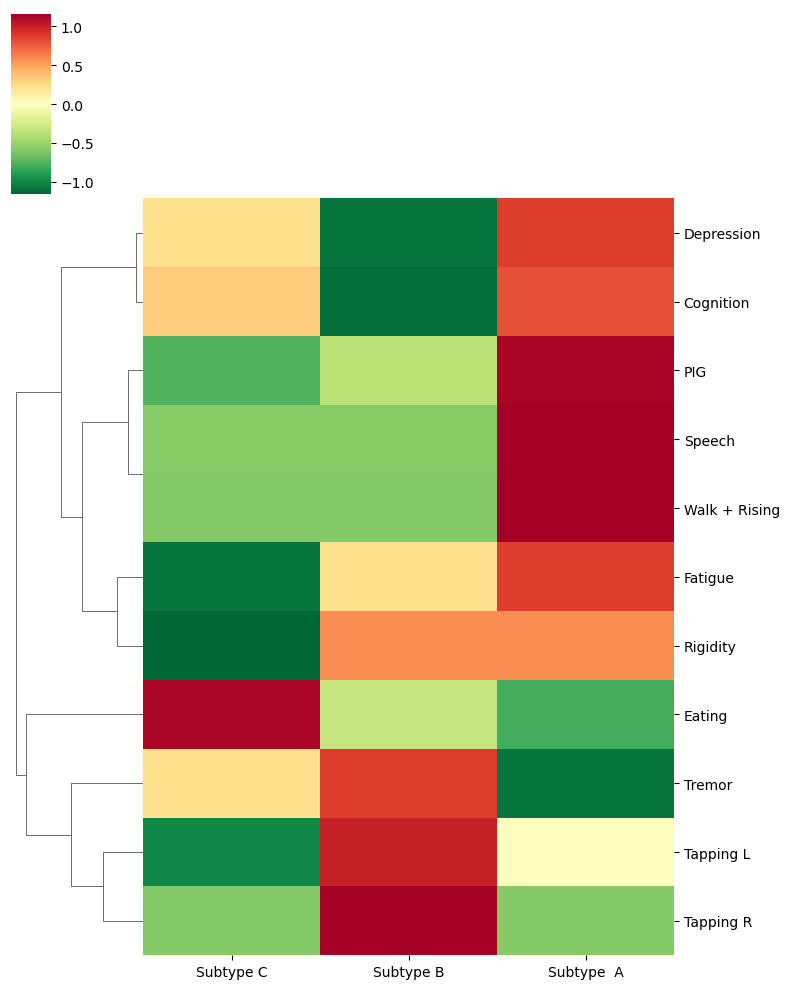

In [10]:
df = abs(pd.DataFrame(score , index = Feat_label))
df.columns = ['Subtype C' , 'Subtype B' , 'Subtype  A']

sns.clustermap(df, cmap='RdYlGn_r', figsize=(8, 10), metric="euclidean" , z_score=0 , col_cluster=False)

# Save the heatmap as an SVG file
plt.savefig("pd_phenotype_char.svg", format='svg')

In [15]:
output.iloc[measure , 3][:4]

'0.13'

In [16]:
output

,Clinical Measure,Feature,R-Squared,Slope Group 0,Slope Group 1,P-Val 0_1,Slope Group 2,P-Val 0_2,P-val 1_2,Int Group 0,Int Group 1,C P-Val 0_1,Int Group 2,C P-Val 0_2,C P-val 1_2
0,MDS-UPDRRS,P1_Factor_1,0.063,0.08 ± 0.02,0.10 ± 0.03,0.065,0.11 ± 0.03,0.053,0.737,-0.40 ± 0.10,-0.33 ± 0.12,0.223,-0.30 ± 0.13,0.120,0.576
1,MDS-UPDRRS,P1_Factor_2,0.007,0.03 ± 0.02,0.01 ± 0.03,0.179,0.04 ± 0.03,0.774,0.066,-0.15 ± 0.09,-0.07 ± 0.11,0.201,-0.04 ± 0.12,0.085,0.485
2,MDS-UPDRRS,P1_Factor_3,0.048,0.08 ± 0.02,0.05 ± 0.02,0.021,0.09 ± 0.03,0.543,0.001,-0.28 ± 0.08,-0.20 ± 0.09,0.105,-0.27 ± 0.10,0.892,0.100
3,MDS-UPDRRS,P2_Factor_1,0.087,0.09 ± 0.02,0.09 ± 0.02,0.858,0.10 ± 0.02,0.357,0.183,-0.39 ± 0.08,-0.28 ± 0.09,0.022,-0.31 ± 0.10,0.111,0.553
4,MDS-UPDRRS,P2_Factor_2,0.113,0.13 ± 0.02,0.13 ± 0.03,0.799,0.15 ± 0.03,0.381,0.173,-0.49 ± 0.10,-0.47 ± 0.11,0.732,-0.40 ± 0.13,0.156,0.171
5,MDS-UPDRRS,P2_Factor_3,0.008,0.05 ± 0.02,0.02 ± 0.03,0.026,0.01 ± 0.03,0.002,0.196,-0.13 ± 0.09,-0.09 ± 0.11,0.517,-0.05 ± 0.12,0.217,0.422
6,MDS-UPDRRS,P3_Factor_1,0.036,0.06 ± 0.03,0.10 ± 0.04,0.022,0.08 ± 0.04,0.395,0.136,-0.42 ± 0.13,-0.29 ± 0.15,0.105,-0.16 ± 0.17,0.002,0.052
7,MDS-UPDRRS,P3_Factor_2,0.018,0.06 ± 0.03,0.07 ± 0.04,0.444,0.06 ± 0.04,0.740,0.661,-0.17 ± 0.13,-0.21 ± 0.15,0.587,-0.28 ± 0.17,0.183,0.299
8,MDS-UPDRRS,P3_Factor_3,0.098,0.13 ± 0.03,0.14 ± 0.03,0.588,0.18 ± 0.04,0.004,0.004,-0.49 ± 0.12,-0.51 ± 0.14,0.699,-0.48 ± 0.15,0.909,0.567
9,MDS-UPDRRS,P3_Factor_4,0.020,0.06 ± 0.03,0.08 ± 0.03,0.153,0.02 ± 0.04,0.034,0.000,-0.14 ± 0.11,-0.29 ± 0.13,0.027,-0.07 ± 0.15,0.341,0.000


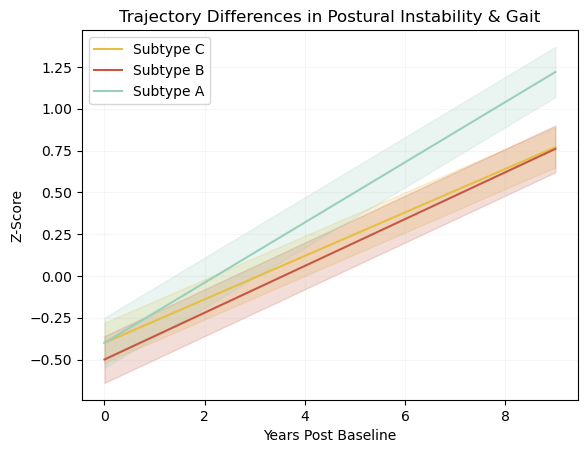

In [24]:
m_loc = [3,4,6]
c_loc = [9,10,12]
labels = ['Subtype C' , 'Subtype B' , 'Subtype A'] 
measure = 8
for i , (m , c) in enumerate(zip(m_loc , c_loc)) : 
    plt.plot(x , np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]) , label = labels[i] , c = wes.FantasticFox2_5.hex_colors[i])
    plt.fill_between(x , (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))-np.float32(output.iloc[measure , c][7:]),
                     (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))+np.float32(output.iloc[measure , c][7:]) , 
                    alpha=0.2 , color = wes.FantasticFox2_5.hex_colors[i] )

plt.legend()
plt.xlabel('Years Post Baseline')
plt.ylabel('Z-Score')
plt.grid(alpha=0.1)
plt.title('Trajectory Differences in Postural Instability & Gait')
plt.savefig('../Results/PIG.png' , bbox_inches='tight')

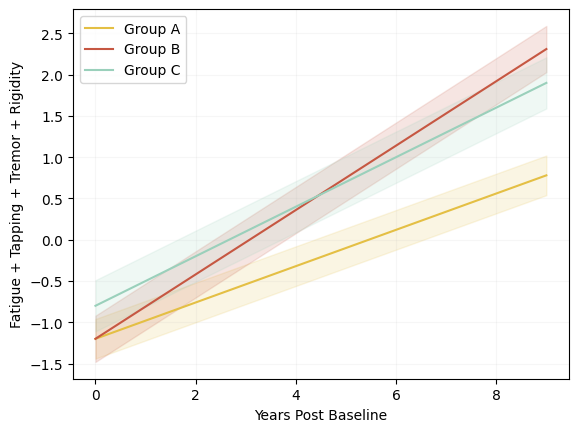

In [161]:
m_loc = [3,4,6]
c_loc = [9,10,12]
labels = ['Group A' , 'Group B' , 'Group C'] 
measure = 1
for i , (m , c) in enumerate(zip(m_loc , c_loc)) : 
    plt.plot(x , np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]) , label = labels[i] , c = wes.FantasticFox2_5.hex_colors[i])
    plt.fill_between(x , (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))-np.float32(output.iloc[measure , c][7:]),
                     (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))+np.float32(output.iloc[measure , c][7:]) , 
                    alpha=0.15 , color = wes.FantasticFox2_5.hex_colors[i] )

plt.legend()
plt.xlabel('Years Post Baseline')
plt.ylabel('Fatigue + Tapping + Tremor + Rigidity')
plt.grid(alpha=0.1)

In [30]:
output

,Clinical Measure,Feature,R-Squared,Slope Group 0,Slope Group 1,P-Val 0_1,Slope Group 2,P-Val 0_2,P-val 1_2,Int Group 0,Int Group 1,C P-Val 0_1,Int Group 2,C P-Val 0_2,C P-val 1_2
0,MDS-UPDRRS,P1_Factor_1,0.063,0.08 ± 0.02,0.10 ± 0.03,0.065,0.11 ± 0.03,0.053,0.737,-0.40 ± 0.10,-0.33 ± 0.12,0.223,-0.30 ± 0.13,0.120,0.576
1,MDS-UPDRRS,P1_Factor_2,0.007,0.03 ± 0.02,0.01 ± 0.03,0.179,0.04 ± 0.03,0.774,0.066,-0.15 ± 0.09,-0.07 ± 0.11,0.201,-0.04 ± 0.12,0.085,0.485
2,MDS-UPDRRS,P1_Factor_3,0.048,0.08 ± 0.02,0.05 ± 0.02,0.021,0.09 ± 0.03,0.543,0.001,-0.28 ± 0.08,-0.20 ± 0.09,0.105,-0.27 ± 0.10,0.892,0.100
3,MDS-UPDRRS,P2_Factor_1,0.087,0.09 ± 0.02,0.09 ± 0.02,0.858,0.10 ± 0.02,0.357,0.183,-0.39 ± 0.08,-0.28 ± 0.09,0.022,-0.31 ± 0.10,0.111,0.553
4,MDS-UPDRRS,P2_Factor_2,0.113,0.13 ± 0.02,0.13 ± 0.03,0.799,0.15 ± 0.03,0.381,0.173,-0.49 ± 0.10,-0.47 ± 0.11,0.732,-0.40 ± 0.13,0.156,0.171
5,MDS-UPDRRS,P2_Factor_3,0.008,0.05 ± 0.02,0.02 ± 0.03,0.026,0.01 ± 0.03,0.002,0.196,-0.13 ± 0.09,-0.09 ± 0.11,0.517,-0.05 ± 0.12,0.217,0.422
6,MDS-UPDRRS,P3_Factor_1,0.036,0.06 ± 0.03,0.10 ± 0.04,0.022,0.08 ± 0.04,0.395,0.136,-0.42 ± 0.13,-0.29 ± 0.15,0.105,-0.16 ± 0.17,0.002,0.052
7,MDS-UPDRRS,P3_Factor_2,0.018,0.06 ± 0.03,0.07 ± 0.04,0.444,0.06 ± 0.04,0.740,0.661,-0.17 ± 0.13,-0.21 ± 0.15,0.587,-0.28 ± 0.17,0.183,0.299
8,MDS-UPDRRS,P3_Factor_3,0.098,0.13 ± 0.03,0.14 ± 0.03,0.588,0.18 ± 0.04,0.004,0.004,-0.49 ± 0.12,-0.51 ± 0.14,0.699,-0.48 ± 0.15,0.909,0.567
9,MDS-UPDRRS,P3_Factor_4,0.020,0.06 ± 0.03,0.08 ± 0.03,0.153,0.02 ± 0.04,0.034,0.000,-0.14 ± 0.11,-0.29 ± 0.13,0.027,-0.07 ± 0.15,0.341,0.000


In [32]:
output

,Clinical Measure,Feature,R-Squared,Slope Group 0,Slope Group 1,P-Val 0_1,Slope Group 2,P-Val 0_2,P-val 1_2,Int Group 0,Int Group 1,C P-Val 0_1,Int Group 2,C P-Val 0_2,C P-val 1_2
0,MDS-UPDRRS,P1_Factor_1,0.063,0.08 ± 0.02,0.10 ± 0.03,0.065,0.11 ± 0.03,0.053,0.737,-0.40 ± 0.10,-0.33 ± 0.12,0.223,-0.30 ± 0.13,0.120,0.576
1,MDS-UPDRRS,P1_Factor_2,0.007,0.03 ± 0.02,0.01 ± 0.03,0.179,0.04 ± 0.03,0.774,0.066,-0.15 ± 0.09,-0.07 ± 0.11,0.201,-0.04 ± 0.12,0.085,0.485
2,MDS-UPDRRS,P1_Factor_3,0.048,0.08 ± 0.02,0.05 ± 0.02,0.021,0.09 ± 0.03,0.543,0.001,-0.28 ± 0.08,-0.20 ± 0.09,0.105,-0.27 ± 0.10,0.892,0.100
3,MDS-UPDRRS,P2_Factor_1,0.087,0.09 ± 0.02,0.09 ± 0.02,0.858,0.10 ± 0.02,0.357,0.183,-0.39 ± 0.08,-0.28 ± 0.09,0.022,-0.31 ± 0.10,0.111,0.553
4,MDS-UPDRRS,P2_Factor_2,0.113,0.13 ± 0.02,0.13 ± 0.03,0.799,0.15 ± 0.03,0.381,0.173,-0.49 ± 0.10,-0.47 ± 0.11,0.732,-0.40 ± 0.13,0.156,0.171
5,MDS-UPDRRS,P2_Factor_3,0.008,0.05 ± 0.02,0.02 ± 0.03,0.026,0.01 ± 0.03,0.002,0.196,-0.13 ± 0.09,-0.09 ± 0.11,0.517,-0.05 ± 0.12,0.217,0.422
6,MDS-UPDRRS,P3_Factor_1,0.036,0.06 ± 0.03,0.10 ± 0.04,0.022,0.08 ± 0.04,0.395,0.136,-0.42 ± 0.13,-0.29 ± 0.15,0.105,-0.16 ± 0.17,0.002,0.052
7,MDS-UPDRRS,P3_Factor_2,0.018,0.06 ± 0.03,0.07 ± 0.04,0.444,0.06 ± 0.04,0.740,0.661,-0.17 ± 0.13,-0.21 ± 0.15,0.587,-0.28 ± 0.17,0.183,0.299
8,MDS-UPDRRS,P3_Factor_3,0.098,0.13 ± 0.03,0.14 ± 0.03,0.588,0.18 ± 0.04,0.004,0.004,-0.49 ± 0.12,-0.51 ± 0.14,0.699,-0.48 ± 0.15,0.909,0.567
9,MDS-UPDRRS,P3_Factor_4,0.020,0.06 ± 0.03,0.08 ± 0.03,0.153,0.02 ± 0.04,0.034,0.000,-0.14 ± 0.11,-0.29 ± 0.13,0.027,-0.07 ± 0.15,0.341,0.000


In [35]:
output.iloc[measure , : ]

Clinical Measure      MDS-UPDRRS
Feature              P1_Factor_3
R-Squared                  0.048
Slope Group 0        0.08 ± 0.02
Slope Group 1        0.05 ± 0.02
P-Val 0_1                  0.021
Slope Group 2        0.09 ± 0.03
P-Val 0_2                  0.543
P-val 1_2                  0.001
Int Group 0         -0.28 ± 0.08
Int Group 1         -0.20 ± 0.09
C P-Val 0_1                0.105
Int Group 2         -0.27 ± 0.10
C P-Val 0_2                0.892
C P-val 1_2                  0.1
Name: 2, dtype: object

In [36]:
output.iloc[measure , :]

Clinical Measure      MDS-UPDRRS
Feature              P1_Factor_3
R-Squared                  0.048
Slope Group 0        0.08 ± 0.02
Slope Group 1        0.05 ± 0.02
P-Val 0_1                  0.021
Slope Group 2        0.09 ± 0.03
P-Val 0_2                  0.543
P-val 1_2                  0.001
Int Group 0         -0.28 ± 0.08
Int Group 1         -0.20 ± 0.09
C P-Val 0_1                0.105
Int Group 2         -0.27 ± 0.10
C P-Val 0_2                0.892
C P-val 1_2                  0.1
Name: 2, dtype: object

In [12]:
output

,Clinical Measure,Feature,R-Squared,Slope Group 0,Slope Group 1,P-Val 0_1,Slope Group 2,P-Val 0_2,P-val 1_2,Int Group 0,Int Group 1,C P-Val 0_1,Int Group 2,C P-Val 0_2,C P-val 1_2
0,MDS-UPDRRS,P1_Factor_1,0.063,0.08 ± 0.02,0.10 ± 0.03,0.065,0.11 ± 0.03,0.053,0.737,-0.40 ± 0.10,-0.33 ± 0.12,0.223,-0.30 ± 0.13,0.120,0.576
1,MDS-UPDRRS,P1_Factor_2,0.007,0.03 ± 0.02,0.01 ± 0.03,0.179,0.04 ± 0.03,0.774,0.066,-0.15 ± 0.09,-0.07 ± 0.11,0.201,-0.04 ± 0.12,0.085,0.485
2,MDS-UPDRRS,P1_Factor_3,0.048,0.08 ± 0.02,0.05 ± 0.02,0.021,0.09 ± 0.03,0.543,0.001,-0.28 ± 0.08,-0.20 ± 0.09,0.105,-0.27 ± 0.10,0.892,0.100
3,MDS-UPDRRS,P2_Factor_1,0.087,0.09 ± 0.02,0.09 ± 0.02,0.858,0.10 ± 0.02,0.357,0.183,-0.39 ± 0.08,-0.28 ± 0.09,0.022,-0.31 ± 0.10,0.111,0.553
4,MDS-UPDRRS,P2_Factor_2,0.113,0.13 ± 0.02,0.13 ± 0.03,0.799,0.15 ± 0.03,0.381,0.173,-0.49 ± 0.10,-0.47 ± 0.11,0.732,-0.40 ± 0.13,0.156,0.171
5,MDS-UPDRRS,P2_Factor_3,0.008,0.05 ± 0.02,0.02 ± 0.03,0.026,0.01 ± 0.03,0.002,0.196,-0.13 ± 0.09,-0.09 ± 0.11,0.517,-0.05 ± 0.12,0.217,0.422
6,MDS-UPDRRS,P3_Factor_1,0.036,0.06 ± 0.03,0.10 ± 0.04,0.022,0.08 ± 0.04,0.395,0.136,-0.42 ± 0.13,-0.29 ± 0.15,0.105,-0.16 ± 0.17,0.002,0.052
7,MDS-UPDRRS,P3_Factor_2,0.018,0.06 ± 0.03,0.07 ± 0.04,0.444,0.06 ± 0.04,0.740,0.661,-0.17 ± 0.13,-0.21 ± 0.15,0.587,-0.28 ± 0.17,0.183,0.299
8,MDS-UPDRRS,P3_Factor_3,0.098,0.13 ± 0.03,0.14 ± 0.03,0.588,0.18 ± 0.04,0.004,0.004,-0.49 ± 0.12,-0.51 ± 0.14,0.699,-0.48 ± 0.15,0.909,0.567
9,MDS-UPDRRS,P3_Factor_4,0.020,0.06 ± 0.03,0.08 ± 0.03,0.153,0.02 ± 0.04,0.034,0.000,-0.14 ± 0.11,-0.29 ± 0.13,0.027,-0.07 ± 0.15,0.341,0.000


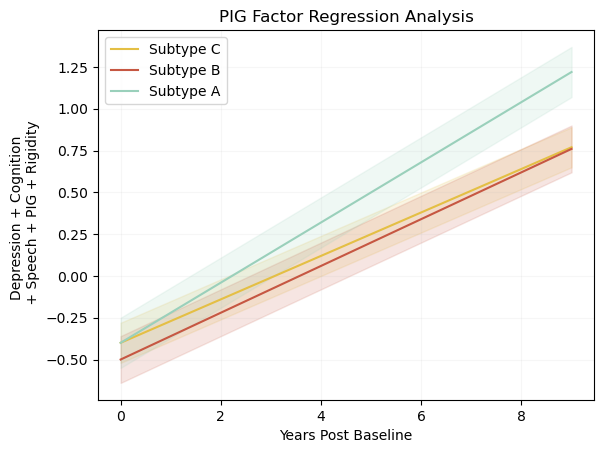

In [11]:
m_loc = [3,4,6]
c_loc = [9,10,12]
labels = ['Subtype C' , 'Subtype B' , 'Subtype A'] 
measure = 8
for i , (m , c) in enumerate(zip(m_loc , c_loc)) : 
    plt.plot(x , np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]) , label = labels[i] , c = wes.FantasticFox2_5.hex_colors[i])
    plt.fill_between(x , (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))-np.float32(output.iloc[measure , c][7:]),
                     (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))+np.float32(output.iloc[measure , c][7:]) , 
                    alpha=0.15 , color = wes.FantasticFox2_5.hex_colors[i] )

plt.legend()
plt.xlabel('Years Post Baseline')
plt.ylabel('Depression + Cognition \n + Speech + PIG + Rigidity')
plt.grid(alpha=0.1)
plt.title('PIG Factor Regression Analysis')
plt.savefig('C4_PIG_Factor.svg')

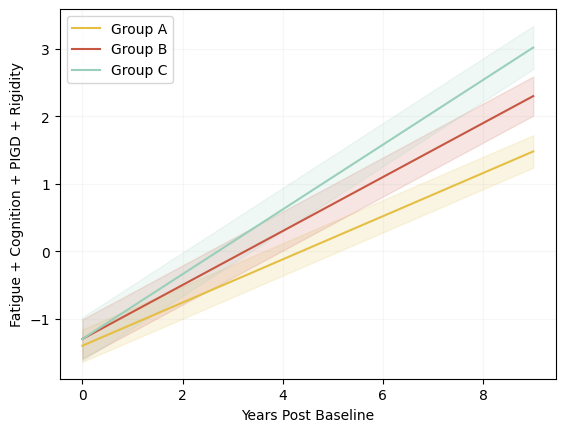

In [163]:
m_loc = [3,4,6]
c_loc = [9,10,12]
labels = ['Group A' , 'Group B' , 'Group C'] 
measure = 3
for i , (m , c) in enumerate(zip(m_loc , c_loc)) : 
    plt.plot(x , np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]) , label = labels[i] , c = wes.FantasticFox2_5.hex_colors[i])
    plt.fill_between(x , (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))-np.float32(output.iloc[measure , c][7:]),
                     (np.float32(output.iloc[measure , m][:4])*x + np.float32(output.iloc[measure , c][:4]))+np.float32(output.iloc[measure , c][7:]) , 
                    alpha=0.15 , color = wes.FantasticFox2_5.hex_colors[i] )

plt.legend()
plt.xlabel('Years Post Baseline')
plt.ylabel('Fatigue + Cognition + PIGD + Rigidity')
plt.grid(alpha=0.1)